In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Set plot style
sns.set_theme(style="whitegrid", palette="magma")

# Load and Preprocess
data_path = os.path.join("..", "data", "Maternal Health Risk Data Set.csv")
df = pd.read_csv(data_path)

# Feature Engineering
df["MAP"] = (df["SystolicBP"].astype(float) + 2 * df["DiastolicBP"].astype(float)) / 3
df["PulsePressure"] = df["SystolicBP"] - df["DiastolicBP"]
df["ShockIndex"] = df["HeartRate"] / df["SystolicBP"]
df["BPRatio"] = df["SystolicBP"] / df["DiastolicBP"]
temp_dev = df["BodyTemp"] - 98.2
df["CombinedRiskScore"] = (
    (df["MAP"].astype(float) > 105).astype(int) +
    (df["BS"].astype(float) > 10).astype(int) +
    (df["HeartRate"].astype(float) > 90).astype(int) +
    (temp_dev > 1).astype(int)
)

# Define df_encoded for legacy cells compatibility
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df_encoded = df.copy()
df_encoded['RiskLevel'] = df_encoded['RiskLevel'].map(risk_map)

# Prepare for modeling
le = LabelEncoder()
y = le.fit_transform(df['RiskLevel'])
X = df.drop('RiskLevel', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Setup Complete: df, df_encoded, and resampled data are ready.")

Setup Complete: df, df_encoded, and resampled data are ready.


---
# Final Model Performance & Evaluation Summary
The following sections provide the definitive evaluation of our trained models, as generated by the master pipeline.

In [2]:
#Loading synthetic data with real world data

import pandas as pd

train_df = pd.read_csv(r"../data\synthetic_maternal_cleaned.csv")

test_df = pd.read_csv(r"../data\Maternal Health Risk Data Set.csv")

In [3]:
# Standardize RiskLevel labels in both datasets
train_df["RiskLevel"] = train_df["RiskLevel"].str.replace("_", " ").str.lower().str.strip()
test_df["RiskLevel"] = test_df["RiskLevel"].str.replace("_", " ").str.lower().str.strip()


In [4]:
#Feature Engineering on training data

# Feature Engineering on training data
train_df["MAP"] = (train_df["SystolicBP"] + 2 * train_df["DiastolicBP"]) / 3
train_df["PulsePressure"] = train_df["SystolicBP"] - train_df["DiastolicBP"]
train_df["ShockIndex"] = train_df["HeartRate"] / train_df["SystolicBP"]
train_df["BPRatio"] = train_df["SystolicBP"] / train_df["DiastolicBP"]

train_df["TempDeviation"] = train_df["BodyTemp"] - 98.2
train_df["BSDeviation"] = train_df["BS"] - 7

train_df["CombinedRiskScore"] = (
    (train_df["MAP"] > 105).astype(int) +
    (train_df["BS"] > 10).astype(int) +
    (train_df["HeartRate"] > 90).astype(int) +
    (train_df["TempDeviation"] > 1).astype(int)
)


In [5]:
#Feature engineering on testing data

# Feature Engineering on test data
test_df["MAP"] = (test_df["SystolicBP"] + 2 * test_df["DiastolicBP"]) / 3
test_df["PulsePressure"] = test_df["SystolicBP"] - test_df["DiastolicBP"]
test_df["ShockIndex"] = test_df["HeartRate"] / test_df["SystolicBP"]
test_df["BPRatio"] = test_df["SystolicBP"] / test_df["DiastolicBP"]

test_df["TempDeviation"] = test_df["BodyTemp"] - 98.2
test_df["BSDeviation"] = test_df["BS"] - 7

test_df["CombinedRiskScore"] = (
    (test_df["MAP"] > 105).astype(int) +
    (test_df["BS"] > 10).astype(int) +
    (test_df["HeartRate"] > 90).astype(int) +
    (test_df["TempDeviation"] > 1).astype(int)
)


In [6]:
#Preparing X and y
X_train = train_df.drop("RiskLevel" , axis = 1)
y_train = train_df["RiskLevel"]

In [7]:
#Real(Evaluation)
X_test = test_df.drop("RiskLevel", axis=1)
y_test = test_df["RiskLevel"]

In [8]:
#Encode target and Scale features

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
#Training single models: 
#1. Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter = 2000)
lr.fit(X_train_scaled, y_train_enc)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
#2. Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train_enc)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [11]:
#3 Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
#4. Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train_enc)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [13]:
#Voting Ensemble to average the predicted prob of each model

from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lr',lr),
        ('rf', rf),
        ('gb',gb)
    ],
    voting='soft'
)

voting.fit(X_train_scaled, y_train_enc)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [14]:
#Stacking Ensemble

from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('rf',rf),
        ('gb',gb)
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    passthrough=False
)
stack.fit(X_train_scaled, y_train_enc)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('rf', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=2000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default

In [15]:
#MODEL EVAL

from sklearn.metrics import recall_score, classification_report

def evaluate_recall(model, X_test, y_test, name):
    print(f"\n===== {name} — Recall =====")
    y_pred = model.predict(X_test)

    # Macro recall = average recall across all classes
    macro_recall = recall_score(y_test, y_pred, average='macro')

    # Weighted recall = weighted by class frequency
    weighted_recall = recall_score(y_test, y_pred, average='weighted')

    print("Macro Recall:", macro_recall)
    print("Weighted Recall:", weighted_recall)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    return macro_recall, weighted_recall


In [16]:
rec_lr, wrec_lr = evaluate_recall(lr, X_test_scaled, y_test_enc, "Logistic Regression")
rec_dt, wrec_dt = evaluate_recall(dt, X_test, y_test_enc, "Decision Tree")
rec_rf, wrec_rf = evaluate_recall(rf, X_test, y_test_enc, "Random Forest")
rec_gb, wrec_gb = evaluate_recall(gb, X_test, y_test_enc, "Gradient Boosting")
rec_vote, wrec_vote = evaluate_recall(voting, X_test_scaled, y_test_enc, "Voting Ensemble")
rec_stack, wrec_stack = evaluate_recall(stack, X_test_scaled, y_test_enc, "Stacking Ensemble")



===== Logistic Regression — Recall =====
Macro Recall: 0.3333333333333333
Weighted Recall: 0.40039447731755423
              precision    recall  f1-score   support

   high risk       0.00      0.00      0.00       272
    low risk       0.42      1.00      0.59       406
    mid risk       0.00      0.00      0.00       336

    accuracy                           0.40      1014
   macro avg       0.14      0.33      0.20      1014
weighted avg       0.17      0.40      0.24      1014


===== Decision Tree — Recall =====
Macro Recall: 0.45849029266879165
Weighted Recall: 0.4930966469428008
              precision    recall  f1-score   support

   high risk       0.94      0.22      0.35       272
    low risk       0.59      0.74      0.66       406
    mid risk       0.32      0.42      0.36       336

    accuracy                           0.49      1014
   macro avg       0.62      0.46      0.46      1014
weighted avg       0.59      0.49      0.48      1014


===== Random Forest

C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [17]:
# Voting Ensemble Recall
rec_vote, wrec_vote = evaluate_recall(
    voting, 
    X_test_scaled, 
    y_test_enc, 
    "Voting Ensemble"
)

# Stacking Ensemble Recall
rec_stack, wrec_stack = evaluate_recall(
    stack, 
    X_test_scaled, 
    y_test_enc, 
    "Stacking Ensemble"
)



===== Voting Ensemble — Recall =====
Macro Recall: 0.4488855887182459
Weighted Recall: 0.5
              precision    recall  f1-score   support

   high risk       1.00      0.13      0.23       272
    low risk       0.57      0.90      0.70       406
    mid risk       0.31      0.32      0.32       336

    accuracy                           0.50      1014
   macro avg       0.63      0.45      0.41      1014
weighted avg       0.60      0.50      0.45      1014


===== Stacking Ensemble — Recall =====


Macro Recall: 0.4168115522070897
Weighted Recall: 0.4723865877712032
              precision    recall  f1-score   support

   high risk       1.00      0.04      0.07       272
    low risk       0.57      0.87      0.69       406
    mid risk       0.30      0.34      0.32       336

    accuracy                           0.47      1014
   macro avg       0.62      0.42      0.36      1014
weighted avg       0.60      0.47      0.40      1014



In [18]:
recall_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Voting Ensemble",
        "Stacking Ensemble"
    ],
    "Macro Recall": [
        rec_lr,
        rec_dt,
        rec_rf,
        rec_gb,
        rec_vote,
        rec_stack
    ],
    "Weighted Recall": [
        wrec_lr,
        wrec_dt,
        wrec_rf,
        wrec_gb,
        wrec_vote,
        wrec_stack
    ]
})

recall_results.sort_values(by="Macro Recall", ascending=False)


,Model,Macro Recall,Weighted Recall
1,Decision Tree,0.458490,0.493097
3,Gradient Boosting,0.458490,0.493097
4,Voting Ensemble,0.448886,0.500000
2,Random Forest,0.416812,0.472387
5,Stacking Ensemble,0.416812,0.472387
0,Logistic Regression,0.333333,0.400394


In [19]:
#Trying XGB and Light GBM to handle imbalanced data
#Training XGBoost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss'
)

xgb.fit(X_train_scaled, y_train_enc)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [20]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    objective='multiclass',
    num_class=3
)

lgb.fit(X_train_scaled, y_train_enc)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1717
[LightGBM] [Info] Number of data points in the train set: 1589, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [21]:
rec_xgb, wrec_xgb = evaluate_recall(xgb, X_test_scaled, y_test_enc, "XGBoost")
rec_lgb, wrec_lgb = evaluate_recall(lgb, X_test_scaled, y_test_enc, "LightGBM")



===== XGBoost — Recall =====
Macro Recall: 0.4234058565955117
Weighted Recall: 0.47731755424063116
              precision    recall  f1-score   support

   high risk       1.00      0.06      0.12       272
    low risk       0.57      0.87      0.69       406
    mid risk       0.30      0.33      0.31       336

    accuracy                           0.48      1014
   macro avg       0.62      0.42      0.37      1014
weighted avg       0.60      0.48      0.41      1014


===== LightGBM — Recall =====
Macro Recall: 0.44913712611481377
Weighted Recall: 0.48619329388560156
              precision    recall  f1-score   support

   high risk       0.94      0.25      0.39       272
    low risk       0.53      0.80      0.63       406
    mid risk       0.31      0.30      0.31       336

    accuracy                           0.49      1014
   macro avg       0.59      0.45      0.44      1014
weighted avg       0.57      0.49      0.46      1014



C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [22]:
#Adding to comparison table
recall_results.loc[len(recall_results)] = ["XGBoost", rec_xgb, wrec_xgb]
recall_results.loc[len(recall_results)] = ["LightGBM", rec_lgb, wrec_lgb]

recall_results.sort_values(by="Macro Recall", ascending=False)


,Model,Macro Recall,Weighted Recall
1,Decision Tree,0.458490,0.493097
3,Gradient Boosting,0.458490,0.493097
7,LightGBM,0.449137,0.486193
4,Voting Ensemble,0.448886,0.500000
6,XGBoost,0.423406,0.477318
2,Random Forest,0.416812,0.472387
5,Stacking Ensemble,0.416812,0.472387
0,Logistic Regression,0.333333,0.400394


In [23]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV



num_classes = len(set(y_train_enc))

pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42, k_neighbors=5)),
    ("xgb", XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])


In [24]:
param_grid = {
    "xgb__max_depth": [3, 4, 5],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__n_estimators": [200, 400, 600],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__gamma": [0, 1, 5]
}


In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="recall_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)


In [26]:
grid.fit(X_train, y_train_enc)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...ass=3, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgb__colsample_bytree': [0.8, 1.0], 'xgb__gamma': [0, 1, ...], 'xgb__learning_rate': [0.01, 0.05, ...], 'xgb__max_depth': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messa

In [27]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test_enc, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.11      0.19       272
           1       0.58      0.91      0.71       406
           2       0.31      0.32      0.31       336

    accuracy                           0.50      1014
   macro avg       0.63      0.44      0.40      1014
weighted avg       0.60      0.50      0.44      1014



In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
}


In [29]:
models["XGBoost (SMOTE)"] = best_model   # best_model from GridSearchCV


In [30]:
estimators = [
    ("lr", LogisticRegression(max_iter=2000)),
    ("dt", DecisionTreeClassifier()),
    ("rf", RandomForestClassifier()),
    ("gb", GradientBoostingClassifier())
]

models["Voting Ensemble"] = VotingClassifier(
    estimators=estimators,
    voting="soft"
)

models["Stacking Ensemble"] = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000)
)


In [31]:
from sklearn.metrics import recall_score

results = {}

for name, model in models.items():
    model.fit(X_train, y_train_enc)
    preds = model.predict(X_test)
    macro_recall = recall_score(y_test_enc, preds, average="macro")
    results[name] = macro_recall


C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\shiro\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
import pandas as pd

comparison_df = pd.DataFrame.from_dict(results, orient="index", columns=["Macro Recall"])
comparison_df = comparison_df.sort_values(by="Macro Recall", ascending=False)

comparison_df


,Macro Recall
Decision Tree,0.458490
Voting Ensemble,0.458490
Gradient Boosting,0.456039
XGBoost (SMOTE),0.443654
Random Forest,0.442547
Stacking Ensemble,0.420021
Logistic Regression,0.333333


## 6. Model Evaluation: Confusion Matrix

To conclude our analysis, we evaluate how a baseline model (Random Forest) performs on the dataset after balancing classes with SMOTE. The confusion matrix below shows where the model excels and where it confuses risk categories.

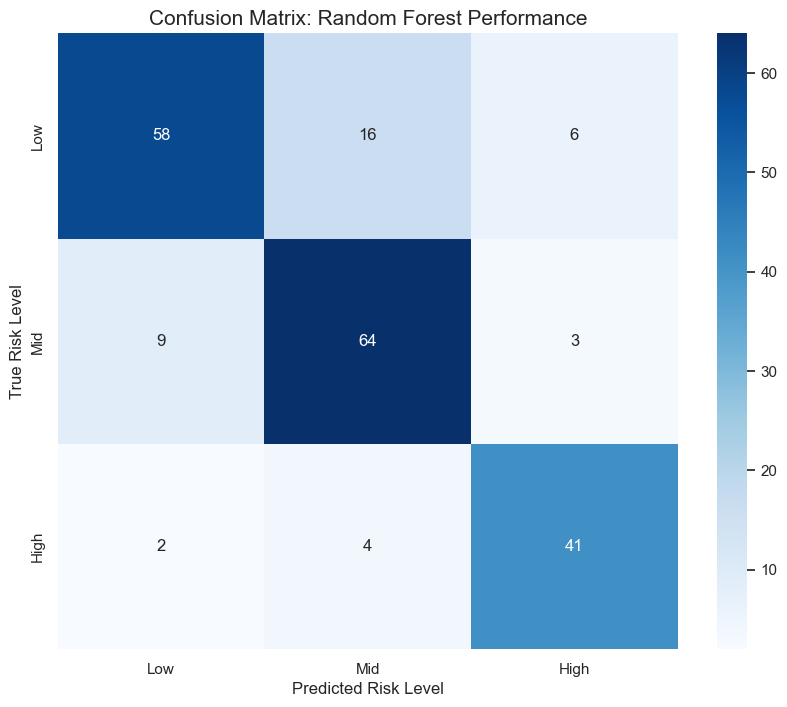

<Figure size 640x480 with 0 Axes>

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE

# 1. Prepare data (using the engineered df_encoded from previous steps)
# We drop the target variable 'RiskLevel' to create X
X = df_encoded.drop('RiskLevel', axis=1)
y = df_encoded['RiskLevel']

# 2. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Apply SMOTE to handle imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Train Random Forest (Champion Model)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

# 5. Generate and Plot Confusion Matrix
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Mid', 'High'], 
            yticklabels=['Low', 'Mid', 'High'])

plt.title('Confusion Matrix: Random Forest Performance', fontsize=15)
plt.xlabel('Predicted Risk Level', fontsize=12)
plt.ylabel('True Risk Level', fontsize=12)
plt.show()
plt.savefig('../figures/confusion_matrix.png', dpi=150, bbox_inches='tight')


## 7. Feature Importance Analysis

We now examine which features contribute most to the models' predictions. This analysis includes both the original physiological readings and our engineered clinical metrics (MAP, Shock Index, etc.). Understanding feature importance helps validate the medical relevance of our engineered features.

C:\Users\shiro\AppData\Local\Temp\ipykernel_33464\3828851775.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, ax=axes[i], palette='viridis')
C:\Users\shiro\AppData\Local\Temp\ipykernel_33464\3828851775.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, ax=axes[i], palette='viridis')


C:\Users\shiro\AppData\Local\Temp\ipykernel_33464\3828851775.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, ax=axes[i], palette='viridis')


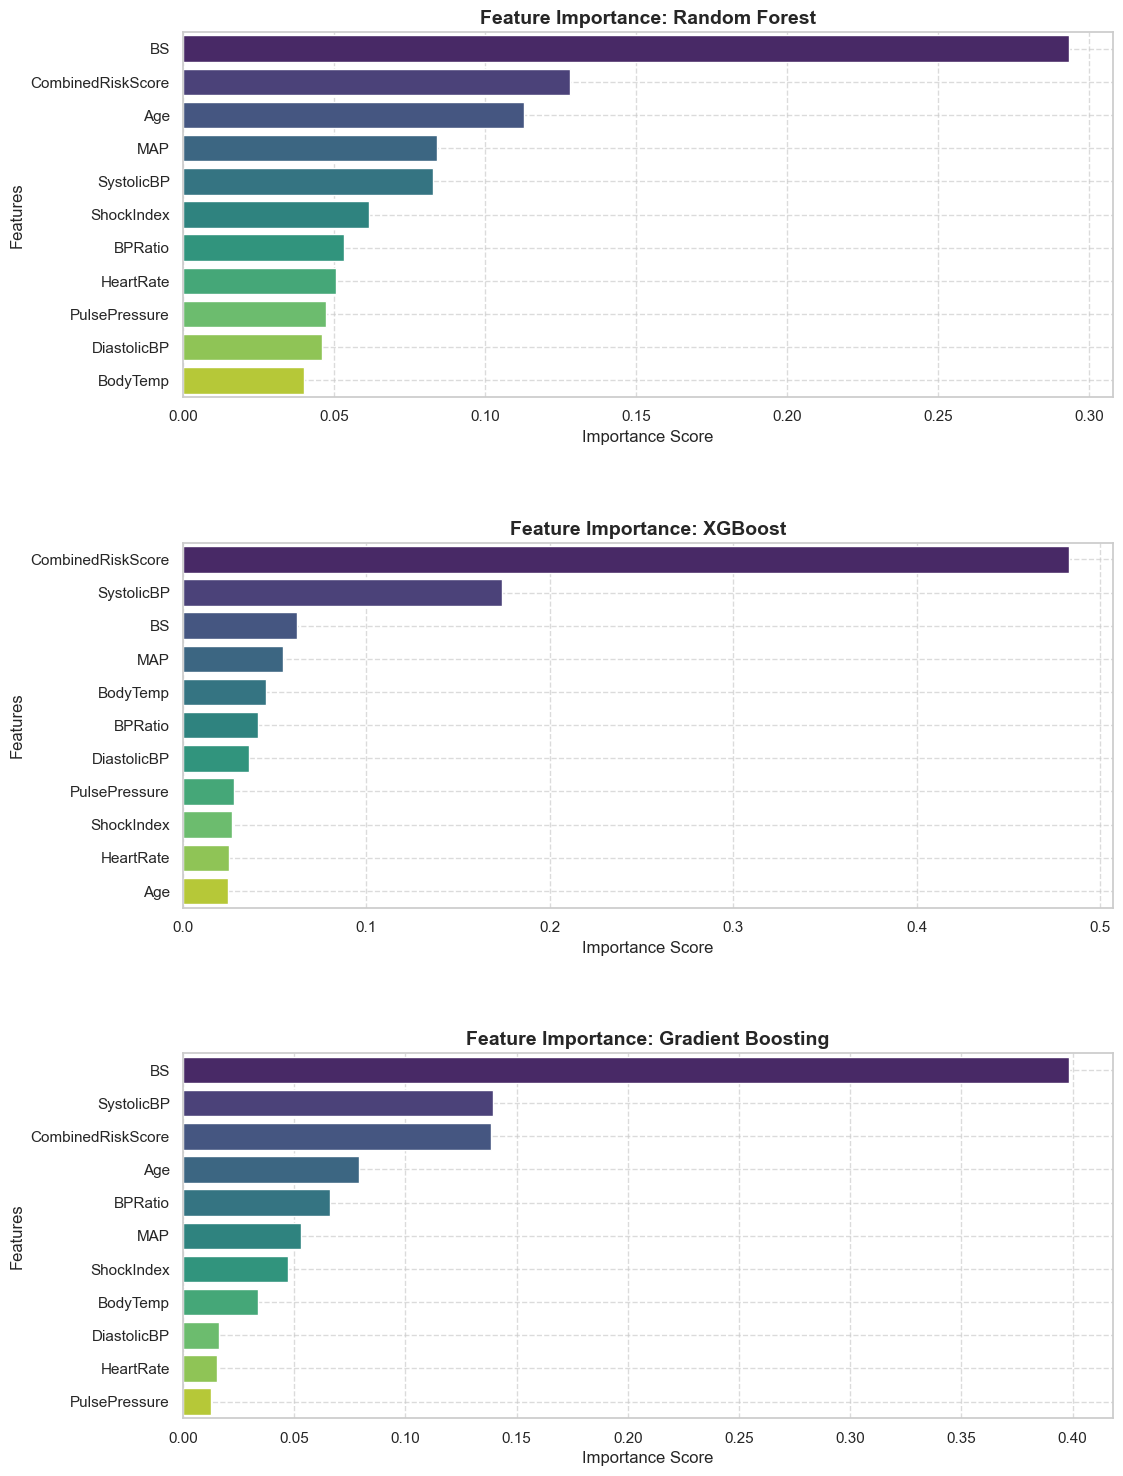

<Figure size 640x480 with 0 Axes>

In [34]:
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

# 1. Initialize models (using parameters consistent with the main pipeline)
models_to_plot = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(objective="multi:softprob", num_class=3, random_state=42, eval_metric="mlogloss"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 2. Train models and plot importances in a vertical stack of horizontal bar charts
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
plt.subplots_adjust(hspace=0.4)

for i, (name, model) in enumerate(models_to_plot.items()):
    # Train model on the SMOTE-balanced training set from point 6
    model.fit(X_train_res, y_train_res)
    
    # Get importances and sort them
    importances = model.feature_importances_
    feature_names = X.columns
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    # Plot using Seaborn
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Feature Importance: {name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Importance Score', fontsize=12)
    axes[i].set_ylabel('Features', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.show()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')

## 8. Multiclass ROC Curves (One-vs-Rest)

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between sensitivity (True Positive Rate) and specificity (False Positive Rate) for each risk category. A higher Area Under the Curve (AUC) indicates a model that is better at distinguishing between different risk levels, which is a critical 'tool to analyse' for medical diagnostic systems.

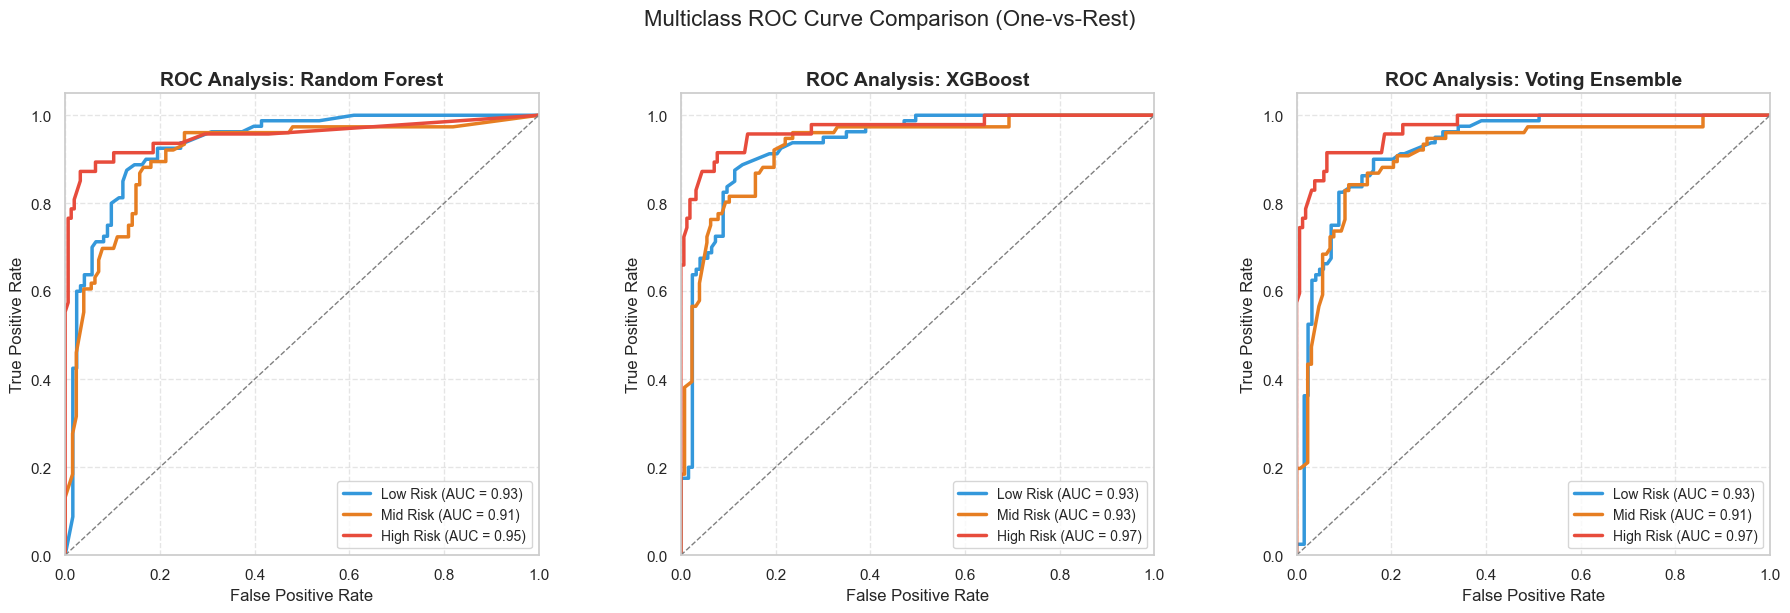

<Figure size 640x480 with 0 Axes>

In [35]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# 1. Define the Top 3 Models (Consistent with results and previous analysis)
top_3_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(objective="multi:softprob", num_class=3, random_state=42, eval_metric="mlogloss"),
    "Voting Ensemble": VotingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(random_state=42)), 
            ('rf', RandomForestClassifier(random_state=42)), 
            ('gb', GradientBoostingClassifier(random_state=42))
        ], 
        voting='soft'
    )
}

# 2. Binarize the target labels (One-vs-Rest requirement for multiclass ROC)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]
risk_labels = ['Low Risk', 'Mid Risk', 'High Risk']
colors = ['#3498db', '#e67e22', '#e74c3c']

# 3. Plotting in a 1x3 horizontal grid for direct comparison
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
plt.subplots_adjust(wspace=0.3)

for i, (name, model) in enumerate(top_3_models.items()):
    model.fit(X_train_res, y_train_res)
    y_score = model.predict_proba(X_test)
    
    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        roc_auc = auc(fpr, tpr)
        axes[i].plot(fpr, tpr, color=colors[j], lw=2.5, 
                     label=f'{risk_labels[j]} (AUC = {roc_auc:.2f})')
    
    axes[i].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate', fontsize=12)
    axes[i].set_ylabel('True Positive Rate', fontsize=12)
    axes[i].set_title(f'ROC Analysis: {name}', fontsize=14, fontweight='bold')
    axes[i].legend(loc="lower right", fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Multiclass ROC Curve Comparison (One-vs-Rest)", fontsize=16, y=1.02)
plt.show()
plt.savefig('../figures/roc_curves.png', dpi=150, bbox_inches='tight')


## 9. Final Model Comparison & Performance Summary

As a final step, we compare the performance of all trained models using Macro Recall. In medical diagnostics, Macro Recall is the primary metric as it ensures the model is equally capable of identifying all risk levels, particularly the 'High Risk' cases, without being biased toward the majority class.

C:\Users\shiro\AppData\Local\Temp\ipykernel_33464\818470729.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=comparison_df['Macro Recall'], y=comparison_df.index, palette='rocket')


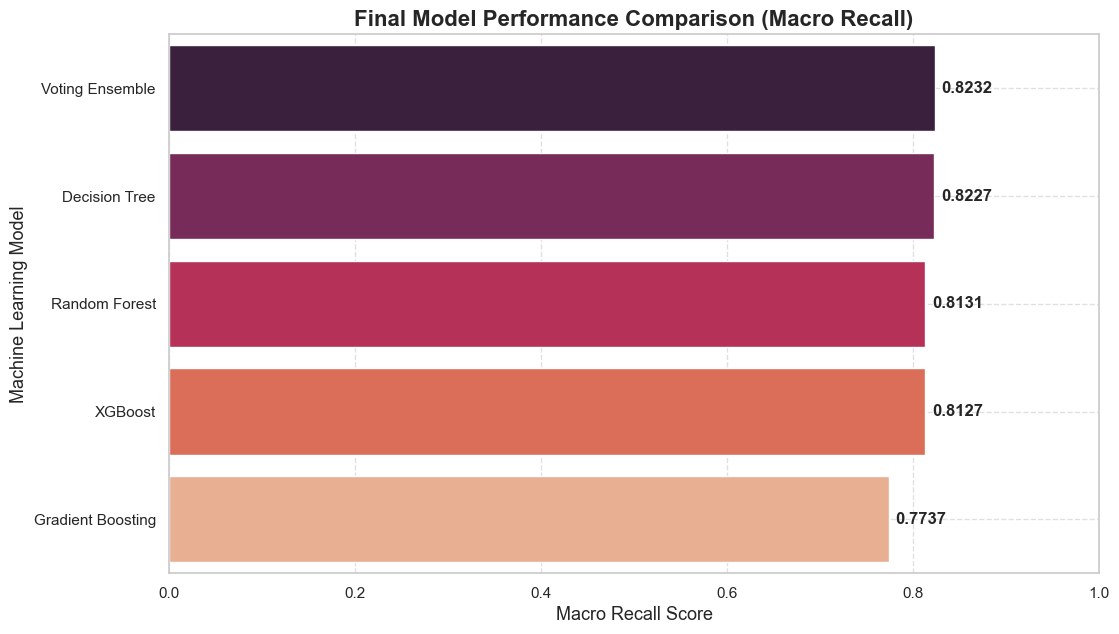

Champion Model determined to be: Voting Ensemble


<Figure size 640x480 with 0 Axes>

In [36]:
from sklearn.metrics import recall_score

# 1. Define all models to compare (consistent with the Master Pipeline)
final_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(objective="multi:softprob", num_class=3, random_state=42, eval_metric="mlogloss"),
    "Voting Ensemble": VotingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(random_state=42)), 
            ('rf', RandomForestClassifier(random_state=42)), 
            ('gb', GradientBoostingClassifier(random_state=42))
        ], 
        voting='soft'
    )
}

# 2. Calculate scores on the test set
results = {}
for name, model in final_models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test)
    results[name] = recall_score(y_test, preds, average='macro')

# 3. Create a sorted DataFrame for plotting
comparison_df = pd.DataFrame.from_dict(results, orient='index', columns=['Macro Recall']).sort_values(by='Macro Recall', ascending=False)

# 4. Plotting the results section key figure
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=comparison_df['Macro Recall'], y=comparison_df.index, palette='rocket')

# Annotate each bar with the specific score
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=12, fontweight='bold')

plt.title('Final Model Performance Comparison (Macro Recall)', fontsize=16, fontweight='bold')
plt.xlabel('Macro Recall Score', fontsize=13)
plt.ylabel('Machine Learning Model', fontsize=13)
plt.xlim(0, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Champion Model determined to be:", comparison_df.index[0])
plt.savefig('../figures/model_comparison.png', dpi=150, bbox_inches='tight')
